# 02 — Nettoyage & Prétraitement des Données

**Objectif :** Corriger les anomalies, imputer les valeurs manquantes, valider la qualité finale.  
**Entrée :** `data/raw/togo_road_accidents_dataset.csv`  
**Sortie :** `data/processed/accidents_clean.parquet`

---

In [ ]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from data_preprocessing import (
    load_raw, clean_strings, fix_date_column, fix_heure_anomalies,
    fix_vitesse_anomalies, fix_cout_negatif, standardize_binary_columns,
    impute_missing_values, remove_duplicates, remove_extreme_outliers,
    encode_target, run_cleaning_pipeline, data_quality_report
)
from utils import quick_info, validate_schema, GRAVITE_COLORS

plt.rcParams['figure.dpi'] = 120
print('Modules chargés ')

Modules chargés ✓


## 1. Chargement des données brutes

In [2]:
df_raw = load_raw('../data/raw/togo_road_accidents_dataset.csv')
quick_info(df_raw)

2026-05-21 19:24:21 | INFO     | preprocessing | Chargement des données brutes depuis ../data/raw/togo_road_accidents_dataset.csv...
2026-05-21 19:24:22 | INFO     | preprocessing |   → 50,500 lignes, 29 colonnes chargées.


Shape     : 50,500 lignes × 29 colonnes
Mémoire   : 59.0 MB
Doublons  : 303

Valeurs manquantes (top 10):
  etat_route                      1,566  (3.1%)
  port_ceinture                   1,564  (3.1%)
  intervention_secours            1,528  (3.0%)
  meteo                           1,515  (3.0%)
  nombre_victimes                 1,485  (2.9%)
  vitesse_estimee                 1,483  (2.9%)
  port_casque                     1,464  (2.9%)
  cause                           1,462  (2.9%)


## 2. Étapes de nettoyage (pas à pas)

2026-05-21 19:24:22 | INFO     | preprocessing |   Heures aberrantes : 8 → correction par modulo 24.


Heures hors [0,23] avant : 8
Heures hors [0,23] après : 0


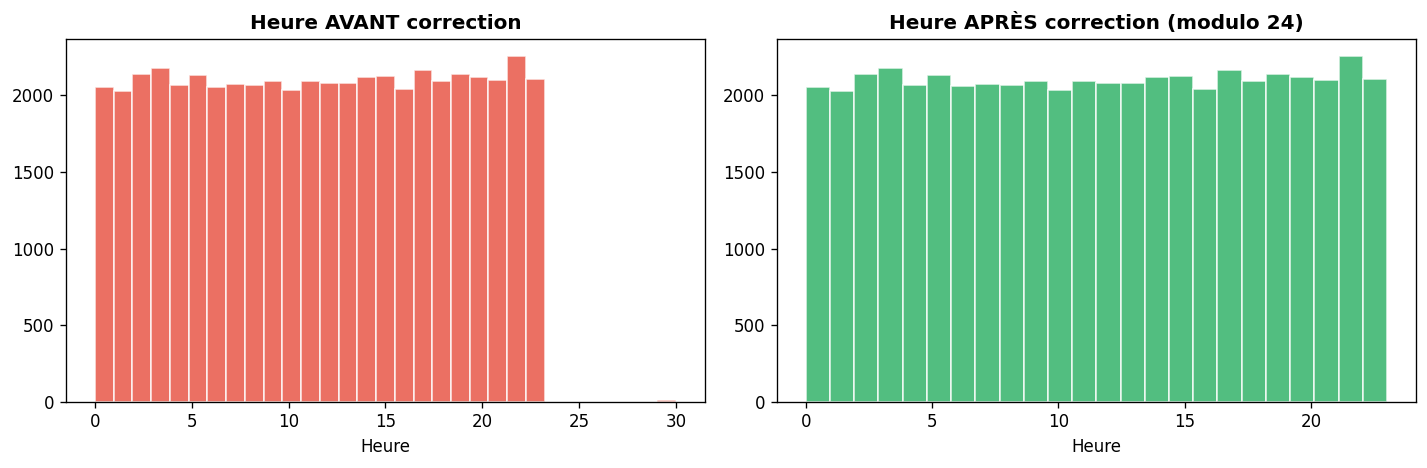

In [3]:
# ── Étape 1 : Heures aberrantes ──────────────────────────────────────────
print('Heures hors [0,23] avant :', ((df_raw['heure'] < 0) | (df_raw['heure'] > 23)).sum())

df_step1 = fix_heure_anomalies(df_raw)
print('Heures hors [0,23] après :', ((df_step1['heure'] < 0) | (df_step1['heure'] > 23)).sum())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_raw['heure'], bins=31, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0].set_title('Heure AVANT correction', fontweight='bold')
axes[0].set_xlabel('Heure')
axes[1].hist(df_step1['heure'], bins=24, color='#27ae60', alpha=0.8, edgecolor='white')
axes[1].set_title('Heure APRÈS correction (modulo 24)', fontweight='bold')
axes[1].set_xlabel('Heure')
plt.tight_layout()
plt.savefig('../reports/figures/02_heure_correction.png', dpi=150, bbox_inches='tight')
plt.show()

2026-05-21 19:24:24 | INFO     | preprocessing |   Vitesses hors plage [0, 200] : 894 valeurs clampées.


Vitesse max avant : 299.0 km/h
Vitesse > 200 km/h : 423
Vitesse max après : 200.0 km/h


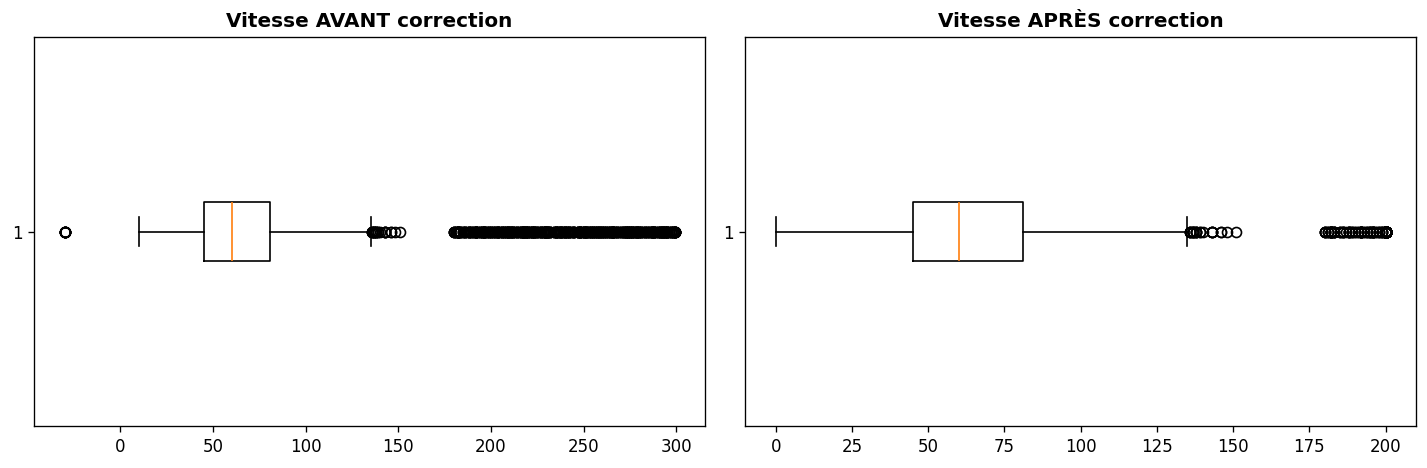

In [4]:
# ── Étape 2 : Vitesses aberrantes ─────────────────────────────────────────
print(f'Vitesse max avant : {df_raw["vitesse_estimee"].max():.1f} km/h')
print(f'Vitesse > 200 km/h : {(df_raw["vitesse_estimee"] > 200).sum()}')

df_step2 = fix_vitesse_anomalies(df_step1)
print(f'Vitesse max après : {df_step2["vitesse_estimee"].max():.1f} km/h')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df_raw['vitesse_estimee'].dropna(), vert=False)
axes[0].set_title('Vitesse AVANT correction', fontweight='bold')
axes[1].boxplot(df_step2['vitesse_estimee'].dropna(), vert=False)
axes[1].set_title('Vitesse APRÈS correction', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/02_vitesse_correction.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── Étape 3 : Imputation des valeurs manquantes ────────────────────────────
print('Valeurs manquantes avant imputation :')
nulls_before = df_step2.isnull().sum()
print(nulls_before[nulls_before > 0])

df_step3 = impute_missing_values(df_step2)

print('\nValeurs manquantes après imputation :')
nulls_after = df_step3.isnull().sum()
print(nulls_after[nulls_after > 0] if (nulls_after > 0).any() else 'Aucune ✓')

Valeurs manquantes avant imputation :
meteo                   1515
nombre_victimes         1485
cause                   1462
etat_route              1566
vitesse_estimee         1483
port_casque             1464
port_ceinture           1564
intervention_secours    1528
dtype: int64


2026-05-21 19:24:25 | INFO     | preprocessing |   meteo : 1515 NaN → 'Soleil'
2026-05-21 19:24:25 | INFO     | preprocessing |   cause : 1462 NaN → 'Inconnue'
2026-05-21 19:24:25 | INFO     | preprocessing |   etat_route : 1566 NaN → mode par region
2026-05-21 19:24:25 | INFO     | preprocessing |   vitesse_estimee : 1483 NaN → médiane par type_route
2026-05-21 19:24:25 | INFO     | preprocessing |   nombre_victimes : 1485 NaN → 1
2026-05-21 19:24:25 | INFO     | preprocessing |   port_casque : 1464 NaN → 'Oui'
2026-05-21 19:24:25 | INFO     | preprocessing |   port_ceinture : 1564 NaN → 'Oui'
2026-05-21 19:24:25 | INFO     | preprocessing |   intervention_secours : 1528 NaN → 40 min



Valeurs manquantes après imputation :
Aucune ✓


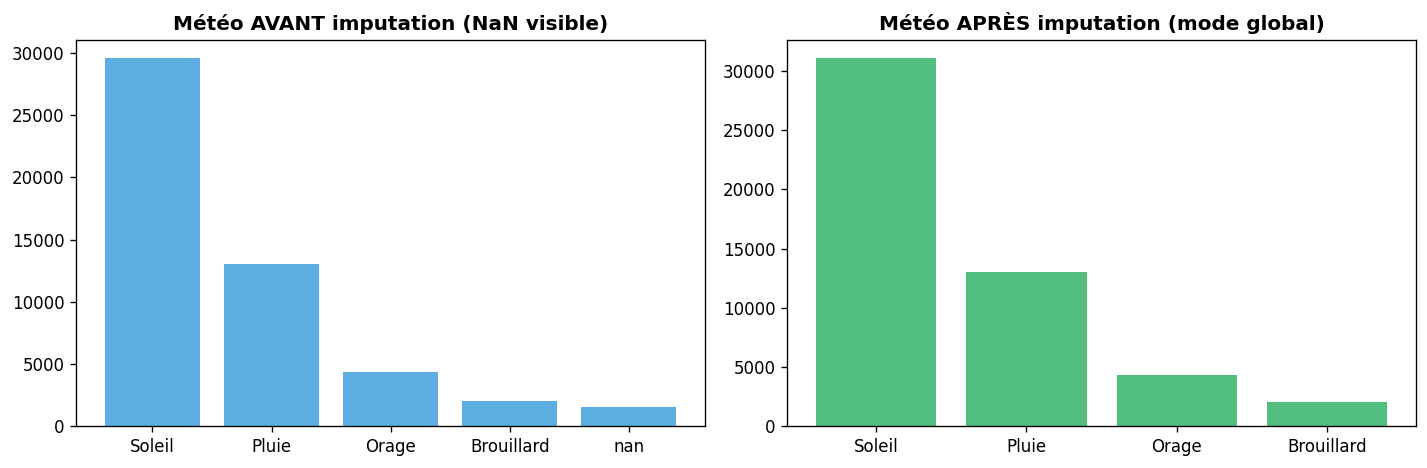

In [6]:
# Visualisation de l'imputation : méteo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

meteo_before = df_step2['meteo'].value_counts(dropna=False)
meteo_after  = df_step3['meteo'].value_counts(dropna=False)

axes[0].bar(meteo_before.index.astype(str), meteo_before.values, color='#3498db', alpha=0.8)
axes[0].set_title('Météo AVANT imputation (NaN visible)', fontweight='bold')

axes[1].bar(meteo_after.index.astype(str), meteo_after.values, color='#27ae60', alpha=0.8)
axes[1].set_title('Météo APRÈS imputation (mode global)', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/02_imputation_meteo.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Pipeline complet de nettoyage

In [7]:
df_clean = run_cleaning_pipeline(
    raw_path=Path('../data/raw/togo_road_accidents_dataset.csv'),
    save_path=Path('../data/processed/accidents_clean.parquet'),
    verbose=True
)

print(f'\nDataset nettoyé : {df_clean.shape}')

2026-05-21 19:24:26 | INFO     | preprocessing | ════════════════════════════════════════════════════════════
2026-05-21 19:24:26 | INFO     | preprocessing | DÉMARRAGE DU PIPELINE DE NETTOYAGE
2026-05-21 19:24:26 | INFO     | preprocessing | ════════════════════════════════════════════════════════════
2026-05-21 19:24:26 | INFO     | preprocessing | Chargement des données brutes depuis ..\data\raw\togo_road_accidents_dataset.csv...
2026-05-21 19:24:26 | INFO     | preprocessing |   → 50,500 lignes, 29 colonnes chargées.


Shape     : 50,500 lignes × 29 colonnes
Mémoire   : 59.0 MB


2026-05-21 19:24:27 | INFO     | preprocessing | 
[1/8] Nettoyage des chaînes de caractères...


Doublons  : 303

Valeurs manquantes (top 10):
  etat_route                      1,566  (3.1%)
  port_ceinture                   1,564  (3.1%)
  intervention_secours            1,528  (3.0%)
  meteo                           1,515  (3.0%)
  nombre_victimes                 1,485  (2.9%)
  vitesse_estimee                 1,483  (2.9%)
  port_casque                     1,464  (2.9%)
  cause                           1,462  (2.9%)


2026-05-21 19:24:27 | INFO     | preprocessing | [2/8] Correction des dates...
2026-05-21 19:24:27 | INFO     | preprocessing | [3/8] Correction des heures aberrantes...
2026-05-21 19:24:27 | INFO     | preprocessing |   Heures aberrantes : 8 → correction par modulo 24.
2026-05-21 19:24:27 | INFO     | preprocessing | [4/8] Correction des vitesses aberrantes...
2026-05-21 19:24:27 | INFO     | preprocessing |   Vitesses hors plage [0, 200] : 894 valeurs clampées.
2026-05-21 19:24:27 | INFO     | preprocessing | [5/8] Correction des coûts négatifs...
2026-05-21 19:24:27 | INFO     | preprocessing | [6/8] Standardisation colonnes binaires...
2026-05-21 19:24:27 | INFO     | preprocessing | [7/8] Imputation des valeurs manquantes...
2026-05-21 19:24:27 | INFO     | preprocessing |   meteo : 1515 NaN → 'Soleil'
2026-05-21 19:24:27 | INFO     | preprocessing |   cause : 1462 NaN → 'Inconnue'
2026-05-21 19:24:27 | INFO     | preprocessing |   etat_route : 1566 NaN → mode par region
2026-05-2

Shape     : 49,783 lignes × 30 colonnes
Mémoire   : 3.1 MB
Doublons  : 0

Valeurs manquantes (top 10):
  Aucune valeur manquante ✓


2026-05-21 19:24:29 | INFO     | utils | DataFrame sauvegardé → ..\data\processed\accidents_clean.parquet (49,783 lignes)
2026-05-21 19:24:29 | INFO     | preprocessing | ════════════════════════════════════════════════════════════
2026-05-21 19:24:29 | INFO     | preprocessing | PIPELINE DE NETTOYAGE TERMINÉ
2026-05-21 19:24:29 | INFO     | preprocessing | ════════════════════════════════════════════════════════════
2026-05-21 19:24:29 | INFO     | utils | [Cleaning Pipeline] Temps d'exécution : 3.33s



Dataset nettoyé : (49783, 30)


## 4. Rapport de qualité avant/après

In [8]:
quality_report = data_quality_report(df_raw, df_clean)
print('RAPPORT DE QUALITÉ')
print('═' * 40)
print(quality_report.to_string())

quality_report.to_csv('../reports/tables/02_quality_report.csv', encoding='utf-8-sig')

RAPPORT DE QUALITÉ
════════════════════════════════════════
                         Valeur
Lignes (brut)          50500.00
Lignes (propre)        49783.00
Lignes supprimées        717.00
Taux de rétention (%)     98.58
Colonnes                  30.00
Mémoire (MB)               3.15
Valeurs manquantes         0.00
Doublons restants          0.00


## 5. Validation du schéma

⚠️ Problèmes de schéma : {'meteo': ['Orage'], 'type_route': ['Nationale', 'Autoroute'], 'type_accident': ['Collision moto'], 'cause': ['Sortie de route', 'Défaillance mécanique', 'Collision piéton', 'Mauvais état route', 'Inconnue']}

Distribution finale de la variable cible :
gravite
Léger     26638
Grave     13260
Mortel     9885
Name: count, dtype: int64


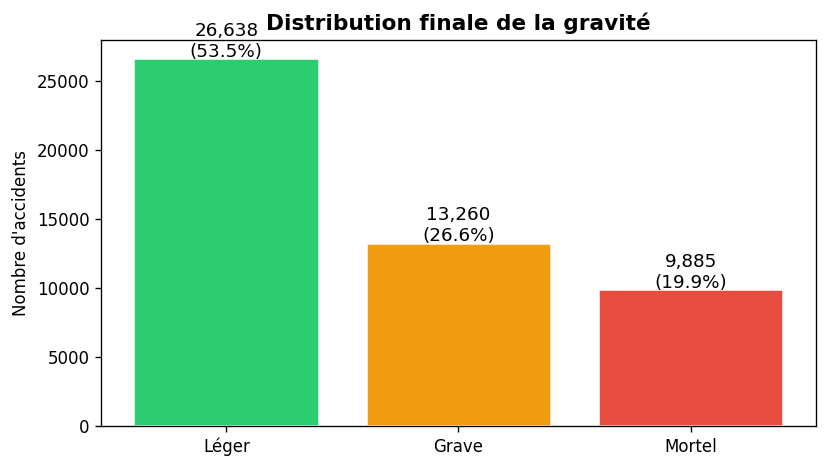

In [ ]:
issues = validate_schema(df_clean)
if issues:
    print(' Problèmes de schéma :', issues)
else:
    print('✓ Schéma validé — toutes les valeurs catégorielles sont conformes')

# Distribution finale de la cible
target_final = df_clean['gravite'].value_counts()
print('\nDistribution finale de la variable cible :')
print(target_final)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [GRAVITE_COLORS[g] for g in target_final.index]
bars = ax.bar(target_final.index, target_final.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, target_final.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}\n({val/len(df_clean)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Distribution finale de la gravité', fontsize=13, fontweight='bold')
ax.set_ylabel('Nombre d\'accidents')
plt.tight_layout()
plt.savefig('../reports/figures/02_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(' Données nettoyées sauvegardées dans data/processed/accidents_clean.parquet')
print(' Prochaine étape : notebook 03_eda_visualization.ipynb')

✓ Données nettoyées sauvegardées dans data/processed/accidents_clean.parquet
→ Prochaine étape : notebook 03_eda_visualization.ipynb
